In [5]:
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt 
from pathlib import Path 
import re
import cv2
import easyocr

In [6]:
import yaml
CONFIG_PATH = "../../configs/laptop.yaml"

with open(CONFIG_PATH, "r", encoding="utf-8") as f:
    cfg = yaml.safe_load(f)

device = cfg["runtime"]["device"]
sample_mode = cfg["runtime"]["sample_mode"]
print(cfg)


{'runtime': {'device': 'cpu', 'sample_mode': True}}


In [7]:
def normalize_timer_text(timer_text: str) -> str:
    if pd.isna(timer_text):
        return ""

    s = str(timer_text).strip()

    # OCRのよくある誤認補正
    s = s.replace("O", "0").replace("o", "0")
    s = s.replace("I", "1").replace("l", "1")

    # コロン誤認を補正
    s = s.replace(".", ":").replace(",", ":").replace(";", ":")

    # 空白を消す
    s = s.replace(" ", "")

    return s

def parse_timer_text_to_sec(timer_text: str):
    if pd.isna(timer_text):
        return np.nan

    s = normalize_timer_text(timer_text)

    # まず普通の m:ss を試す
    m = re.search(r'^(\d{1,2}):(\d{2})$', s)
    if m:
        minute = int(m.group(1))
        second = int(m.group(2))
        if second < 60:
            return minute * 60 + second
        return np.nan

    # コロンが落ちて数字だけになった場合
    digits = "".join(ch for ch in s if ch.isdigit())

    if len(digits) == 3:
        minute = int(digits[0])
        second = int(digits[1:])
    elif len(digits) == 4:
        minute = int(digits[:-2])
        second = int(digits[-2:])
    else:
        return np.nan

    if second >= 60:
        return np.nan

    return minute * 60 + second

In [8]:
def add_padding(img, pad=10, value=255):
    return cv2.copyMakeBorder(
        img,
        pad, pad, pad, pad,
        cv2.BORDER_CONSTANT,
        value=value
    )

def crop_timer_region(frame):
    """
    タイマー領域を切り出す
    """
    h, w = frame.shape[:2]

    # 仮の例: 画面上中央あたり
    x1 = int(w * 0.48)
    x2 = int(w * 0.52)
    y1 = int(h * 0.025)
    y2 = int(h * 0.06)

    return frame[y1:y2, x1:x2]


def preprocess_timer_for_ocr(crop):
    gray = cv2.cvtColor(crop, cv2.COLOR_BGR2GRAY)
    gray = cv2.resize(gray, None, fx=3, fy=3, interpolation=cv2.INTER_CUBIC)

    # 2値化
    _, th = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY + cv2.THRESH_OTSU)
    return th


def read_timer_from_frame(frame, reader):
    crop = crop_timer_region(frame)
    proc = preprocess_timer_for_ocr(crop)

    results = reader.readtext(proc, detail=0, paragraph=False)
    text = "".join(results).strip() if results else ""

    return {
        "timer_text": text,
        "timer_sec": parse_timer_text_to_sec(text),
        "raw_text": results
    }

In [9]:
def scan_video_timer(video_path, reader, sample_fps=2.0):
    """
    動画を一定fpsで走査して timer OCR を行う
    """
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    video_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))

    step = max(1, int(video_fps / sample_fps))

    rows = []

    frame_idx = 0
    while frame_idx < total_frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            break

        t_sec = frame_idx / video_fps
        res = read_timer_from_frame(frame, reader)
        
        rows.append({
            "frame_idx":frame_idx,
            "t_sec": t_sec,
            "timer_text": res["timer_text"],
            "timer_sec": res["timer_sec"],
            "raw_text": res["raw_text"],
        })

        frame_idx += step

    cap.release()
    return pd.DataFrame(rows)

In [10]:
reader = easyocr.Reader(["en"], gpu=sample_mode)

def read_frame_at_sec(video_path, t_sec):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    frame_idx = int(t_sec * fps)
    cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)

    ret, frame = cap.read()
    cap.release()

    if not ret:
        raise ValueError(f"Failed to read frame at {t_sec} sec")

    return frame

Neither CUDA nor MPS are available - defaulting to CPU. Note: This module is much faster with a GPU.


Progress: |██████████████████████████████████████████████████| 100.0% Complete

Progress: |██████████████████████████████████████████████████| 100.0% Complete

c:\Users\ryo16\Desktop\valorant-\.venv\Lib\site-packages\torch\utils\data\dataloader.py:775: UserWarning: 'pin_memory' argument is set as true but no accelerator is found, then device pinned memory won't be used.
  super().__init__(loader)


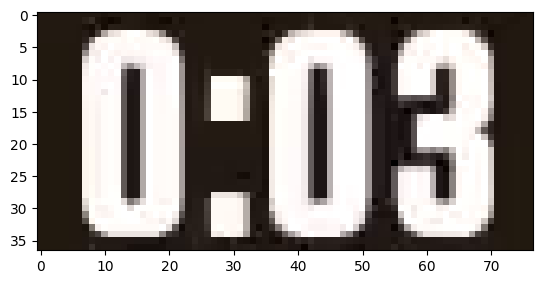

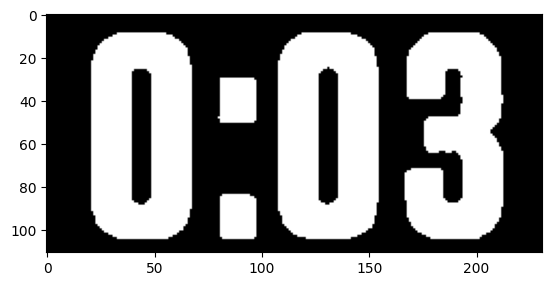

{'timer_text': '0.03', 'timer_sec': 3, 'raw_text': ['0.03']}


In [12]:
t = 3000
video_path = Path("../../data/vods/M8 vs. EDG - VALORANT Masters Santiago - SWISS.mp4")
frame = read_frame_at_sec(video_path,t)

res = read_timer_from_frame(frame=frame,reader=reader)
crop = crop_timer_region(frame)
th = preprocess_timer_for_ocr(crop)
plt.imshow(crop)
plt.show()
plt.imshow(th,cmap="gray")
plt.show()
print(res)


In [ ]:
df = scan_video_timer(video_path, reader, sample_fps=2.0)



In [22]:
def crop_ui_region(frame):
    h, w = frame.shape[:2]

    x1 = int(w * 0.35)
    x2 = int(w * 0.65)
    y1 = int(h * 0.0)
    y2 = int(h * 0.06)

    return frame[y1:y2, x1:x2]

def match_round_template(frame, template, search_region):
    """
    frame: 元フレーム (BGR)
    template: テンプレート画像 (BGR or gray)
    search_region: (x1, y1, x2, y2)
    """
    x1, y1, x2, y2 = search_region
    roi = frame[y1:y2, x1:x2]

    # グレースケール化
    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    
    if len(template.shape) == 3:
        template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)
    else:
        template_gray = template

    # テンプレートマッチング
    result = cv2.matchTemplate(roi_gray, template_gray, cv2.TM_CCOEFF_NORMED)

    min_val, max_val, min_loc, max_loc = cv2.minMaxLoc(result)

    return {
        "score": max_val,
        "top_left": (x1 + max_loc[0], y1 + max_loc[1]),
        "template_w": template_gray.shape[1],
        "template_h": template_gray.shape[0],
    }

In [21]:
def is_round_ui_present(frame, template, search_region, threshold=0.8):
    res = match_round_template(frame, template, search_region)
    return res["score"] >= threshold, res

def show_template_match(frame, template, search_region, threshold=0.8):
    flag, info = is_round_ui_present(frame, template, search_region, threshold)

    x, y = info["top_left"]
    w = info["template_w"]
    h = info["template_h"]

    vis = frame.copy()
    cv2.rectangle(vis, (x, y), (x + w, y + h), (0, 255, 0), 2)

    print("score:", info["score"])
    print("detected:", flag)

    plt.figure(figsize=(14, 6))
    plt.imshow(cv2.cvtColor(vis, cv2.COLOR_BGR2RGB))
    plt.axis("off")
    plt.title("template match result")
    plt.show()

def scan_video_timer_with_gate(video_path, reader, template, search_region, sample_fps=2.0, threshold=0.8):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    video_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, int(video_fps / sample_fps))

    rows = []
    frame_idx = 0

    while frame_idx < total_frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            break

        t_sec = frame_idx / video_fps
        gate_flag, gate_info = is_round_ui_present(frame, template, search_region, threshold)

        if gate_flag:
            res = read_timer_from_frame(frame, reader)
            rows.append({
                "t_sec": t_sec,
                "match_score": gate_info["score"],
                "timer_text": res["timer_text"],
                "timer_sec": res["timer_sec"],
            })

        frame_idx += step

    cap.release()
    return pd.DataFrame(rows)

In [ ]:
template = crop_ui_region(frame)
search_region = (650,0, 1260, 80)
scores = []
for t in [100, 110, 120, 840]:
    frame = read_frame_at_sec(video_path, t)
    res = match_round_template(frame, template, search_region)
    scores.append((t, res["score"]))
    print(t, res["score"])

100 0.07546447962522507
110 0.7591459155082703
120 0.7959889769554138
840 0.9999999403953552


In [ ]:
import time

def scan_video_template(video_path, template, search_region, sample_fps=1.0):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    video_fps = cap.get(cv2.CAP_PROP_FPS)
    total_frames = int(cap.get(cv2.CAP_PROP_FRAME_COUNT))
    step = max(1, int(video_fps / sample_fps))

    rows = []
    frame_idx = 0

    start_time = time.time()

    while frame_idx < total_frames:
        cap.set(cv2.CAP_PROP_POS_FRAMES, frame_idx)
        ret, frame = cap.read()
        if not ret:
            break

        t_sec = frame_idx / video_fps
        res = match_round_template(frame, template, search_region)

        rows.append({
            "frame_idx": frame_idx,
            "t_sec": t_sec,
            "score": res["score"],
            "match_x": res["top_left"][0],
            "match_y": res["top_left"][1],
        })

        frame_idx += step

    elapsed = time.time() - start_time
    cap.release()

    df = pd.DataFrame(rows)
    return df, elapsed

In [ ]:
df_score, elapsed = scan_video_template(
    video_path,
    template,
    search_region,
    sample_fps=1.0
)

print(f"elapsed: {elapsed:.2f} sec")
print(df_score.head())
print(df_score['score'].describe())

elapsed: 723.54 sec
   frame_idx     t_sec     score  match_x  match_y
0          0  0.000000  0.084152      654        0
1         59  0.984317  0.104814      650       16
2        118  1.968633  0.089417      657        0
3        177  2.952950  0.054520      663        0
4        236  3.937267  0.053355      669       16
count    6020.000000
mean        0.547178
std         0.327218
min        -0.139759
25%         0.129325
50%         0.700659
75%         0.790955
max         0.999497
Name: score, dtype: float64


In [ ]:
threshold = 0.4
df_score["is_round_like"] = df_score["score"] >= threshold

print(df_score["is_round_like"].value_counts())
print(df_score[df_score["is_round_like"]].head(20))

is_round_like
True     4169
False    1851
Name: count, dtype: int64
    frame_idx      t_sec     score  match_x  match_y  is_round_like
9         531   8.858850  0.790202      672        0           True
10        590   9.843167  0.799675      672        0           True
11        649  10.827483  0.804149      672        0           True
12        708  11.811800  0.809531      672        0           True
13        767  12.796117  0.810250      672        0           True
14        826  13.780433  0.801616      672        0           True
15        885  14.764750  0.769801      672        0           True
16        944  15.749067  0.771267      672        0           True
17       1003  16.733383  0.787992      672        0           True
18       1062  17.717700  0.775993      672        0           True
19       1121  18.702017  0.774578      672        0           True
20       1180  19.686333  0.781089      672        0           True
21       1239  20.670650  0.779196      672     

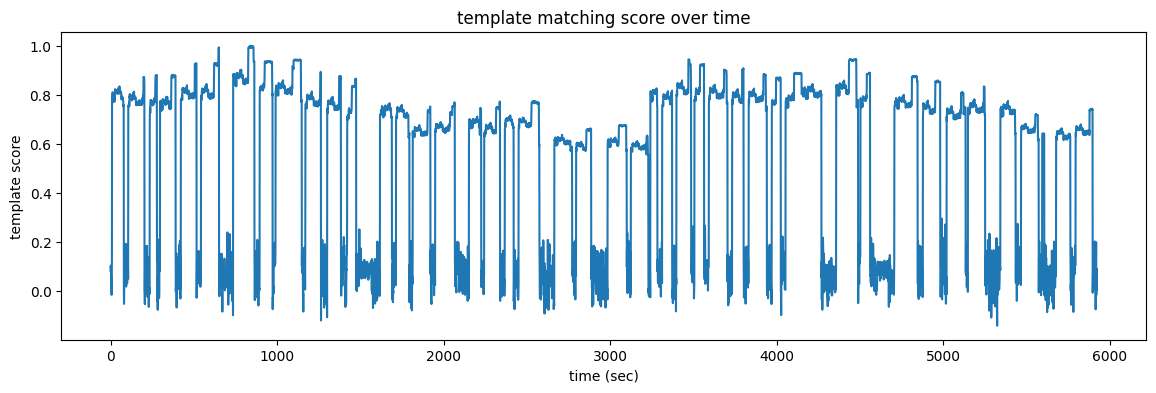

In [ ]:

plt.figure(figsize=(14, 4))
plt.plot(df_score["t_sec"], df_score["score"])
plt.xlabel("time (sec)")
plt.ylabel("template score")
plt.title("template matching score over time")
plt.show()

cv2.matchTemplateは探して判定するから時間がかかるっぽいので単純比較をする

In [52]:
def compare_ui_roi(frame, template):
    roi = crop_ui_region(frame)

    roi_gray = cv2.cvtColor(roi, cv2.COLOR_BGR2GRAY)
    template_gray = cv2.cvtColor(template, cv2.COLOR_BGR2GRAY)

    diff = np.mean(np.abs(roi_gray.astype(np.float32) - template_gray.astype(np.float32)))

    return {"diff": diff}


def scan_ui_diff(video_path, template, interval_sec=1.0, threshold=30.0):
    cap = cv2.VideoCapture(str(video_path))
    if not cap.isOpened():
        raise ValueError(f"Cannot open video: {video_path}")

    fps = cap.get(cv2.CAP_PROP_FPS)
    if fps <= 0:
        cap.release()
        raise ValueError("Invalid FPS")

    step = max(1, int(round(interval_sec * fps)))
    frame_idx = 0
    rows = []

    while True:
        ret, frame = cap.read()
        if not ret:
            break

        if frame_idx % step == 0:
            t_sec = frame_idx / fps
            res = compare_ui_roi(frame, template)
            diff = res["diff"]

            rows.append({
                "frame_idx": frame_idx,
                "t_sec": t_sec,
                "diff": diff,
                "is_round_like": diff < threshold,
            })

        frame_idx += 1

    cap.release()
    return pd.DataFrame(rows)

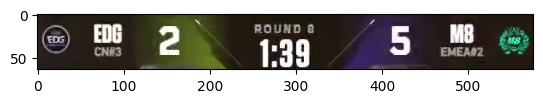

26.428467


In [50]:
template = crop_ui_region(frame)
for t in [896]:
    frame_temp = read_frame_at_sec(video_path, t)
    diff = compare_ui_roi(frame_temp,template)
    plt.imshow(crop_ui_region(frame_temp))
    plt.show()
    print(diff["diff"])


In [53]:
df = scan_ui_diff(video_path, template, interval_sec=1.0, threshold=15.0)
df.head()

,frame_idx,t_sec,diff,is_round_like
0,0,0.000,45.209797,False
1,60,1.001,44.032742,False
2,120,2.002,44.441788,False
3,180,3.003,44.651016,False
4,240,4.004,43.625107,False


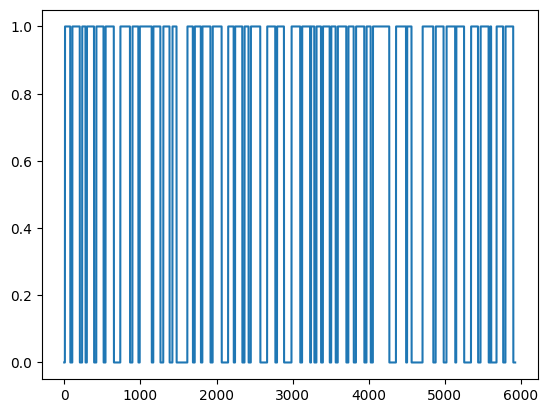

In [62]:
plt.plot(df["t_sec"],df["is_round_like"])
plt.show()

In [63]:
def detect_transition(df,col="is_round_like"):
    out = df.copy()
    s = out[col]
    out["start"] = (~s.shift(1,fill_value=False)) & s
    out["end"] = s & (~s.shift(-1,fill_value=False))
    return out

In [64]:
df = detect_transition(df)
df["start"].sum()

np.int64(44)